In [1]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/drive/MyDrive/NN_project/data.zip /content/
!cp /content/drive/MyDrive/NN_project/src.zip /content/
!cp /content/drive/MyDrive/NN_project/scripts.zip /content/

!unzip -q /content/data.zip -d /content/
!unzip -q /content/src.zip -d /content/
!unzip -q /content/scripts.zip -d /content/

!pip install torchmetrics

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.1 MB/s eta 0:00:00


In [2]:
# Wprowadzamy downsampling convolutions oraz trzecią głowę - offset

import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
from torchvision.transforms import v2
from torchmetrics.detection.mean_ap import MeanAveragePrecision

sys.path.append('/content/')

from src.datasets.dataset import PKLotDataset, collate_fn
from src.models.custom_detector3 import SimpleUNetCenterNet, create_centernet_targets, focal_loss, reg_l1_loss

def get_transform(is_train=True):
    transforms = [
        v2.ToImage(),
        v2.Resize(size=(360, 640), antialias=True),
    ]
    if is_train:
        transforms.extend([
            v2.RandomHorizontalFlip(p=0.5),
            v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
        ])
    transforms.append(v2.ToDtype(torch.float32, scale=True))
    return v2.Compose(transforms)

def decode_predictions(pred_hm, pred_wh, pred_offset, threshold=0.3):
    """
    Zamienia mapy cieplne na bounding boxy, uwzględniając poprawkę z głowy offset.
    """
    B, C, H, W = pred_hm.shape
    results = []

    pool = torch.nn.functional.max_pool2d(pred_hm, kernel_size=3, stride=1, padding=1)
    keep = (pool == pred_hm).float()
    pred_hm = pred_hm * keep

    for b in range(B):
        hm = pred_hm[b]
        wh = pred_wh[b]
        offset = pred_offset[b] # [2, H, W]

        boxes = []
        scores = []
        labels = []

        for class_idx in range(C):
            class_hm = hm[class_idx]
            ys, xs = torch.where(class_hm > threshold)

            for y, x in zip(ys, xs):
                score = class_hm[y, x].item()
                w = wh[0, y, x].item()
                h = wh[1, y, x].item()

                dx = offset[0, y, x].item()
                dy = offset[1, y, x].item()

                # Prawdziwy, skorygowany środek
                center_x = x.item() + dx
                center_y = y.item() + dy

                # Wyliczanie krawędzi za pomocą skorygowanego środka
                x_min = center_x - w / 2
                y_min = center_y - h / 2
                x_max = center_x + w / 2
                y_max = center_y + h / 2

                boxes.append([x_min, y_min, x_max, y_max])
                scores.append(score)
                labels.append(class_idx + 1)

        if len(boxes) > 0:
            results.append({
                "boxes": torch.tensor(boxes, dtype=torch.float32, device=pred_hm.device),
                "scores": torch.tensor(scores, dtype=torch.float32, device=pred_hm.device),
                "labels": torch.tensor(labels, dtype=torch.int64, device=pred_hm.device)
            })
        else:
            results.append({
                "boxes": torch.empty((0, 4), dtype=torch.float32, device=pred_hm.device),
                "scores": torch.empty((0,), dtype=torch.float32, device=pred_hm.device),
                "labels": torch.empty((0,), dtype=torch.int64, device=pred_hm.device)
            })

    return results

def train_model(model, EPOCHS, transform, subset_size, id, val_subset, device):
    full_train_dataset = PKLotDataset(
        root_dir="/content/data/raw/train",
        annotation_file="/content/data/raw/train/_annotations.coco.json",
        transforms=transform(is_train=True)
    )
    train_subset_size = min(subset_size, len(full_train_dataset))
    train_indices = np.random.choice(len(full_train_dataset), train_subset_size, replace=False)
    train_dataset = Subset(full_train_dataset, train_indices)

    train_loader = DataLoader(
        train_dataset,
        batch_size=8,
        shuffle=True,
        num_workers=2,
        collate_fn=collate_fn
    )

    full_val_dataset = PKLotDataset(
        root_dir="/content/data/raw/valid",
        annotation_file="/content/data/raw/valid/_annotations.coco.json",
        transforms=transform(is_train=False)
    )
    val_subset_size = min(val_subset, len(full_val_dataset))
    val_indices = np.random.choice(len(full_val_dataset), val_subset_size, replace=False)
    val_dataset = Subset(full_val_dataset, val_indices)

    val_loader = DataLoader(
        val_dataset,
        batch_size=8,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fn
    )

    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=0.0003, weight_decay=0.0005)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    train_losses = []
    val_losses = []

    print("Rozpoczynam trening i walidację ulepszonego CenterNet...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_train_loss = 0
        train_bar = tqdm(train_loader, desc=f"Epoka {epoch+1}/{EPOCHS} [Train]")

        for images, targets in train_bar:
            images = torch.stack([image.to(device) for image in images])
            B, C, H, W = images.shape

            gt_hms, gt_whs, gt_offsets, masks = [], [], [], []
            for t in targets:
                boxes = t["boxes"].to(device)
                labels = t["labels"].to(device)

                # Zbieranie nowych offsetów
                hm, wh, offset, mask = create_centernet_targets(boxes, labels, H, W, device)
                gt_hms.append(hm)
                gt_whs.append(wh)
                gt_offsets.append(offset)
                masks.append(mask)

            gt_hm = torch.stack(gt_hms)
            gt_wh = torch.stack(gt_whs)
            gt_offset = torch.stack(gt_offsets)
            reg_mask = torch.stack(masks)

            preds = model(images)
            pred_hm = preds["heatmap"]
            pred_wh = preds["wh"]
            pred_offset = preds["offset"]

            hm_loss = focal_loss(pred_hm, gt_hm)
            wh_loss = reg_l1_loss(pred_wh, gt_wh, reg_mask)
            # Ta sama funkcja straty co dla WH sprawdzi się świetnie dla offsetu (wymaga reg_mask)
            offset_loss = reg_l1_loss(pred_offset, gt_offset, reg_mask)

            # Są to standardowe parametry wag z oryginalnej pracy o CenterNet
            total_loss = hm_loss + 0.1 * wh_loss + 1.0 * offset_loss

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            epoch_train_loss += total_loss.item()
            train_bar.set_postfix({'hm': f"{hm_loss.item():.2f}", 'wh': f"{wh_loss.item():.2f}", 'off': f"{offset_loss.item():.2f}"})

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        epoch_val_loss = 0
        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f"Epoka {epoch+1}/{EPOCHS} [Valid]")
            for images, targets in val_bar:
                images = torch.stack([image.to(device) for image in images])
                B, C, H, W = images.shape

                gt_hms, gt_whs, gt_offsets, masks = [], [], [], []
                for t in targets:
                    boxes = t["boxes"].to(device)
                    labels = t["labels"].to(device)
                    hm, wh, offset, mask = create_centernet_targets(boxes, labels, H, W, device)
                    gt_hms.append(hm)
                    gt_whs.append(wh)
                    gt_offsets.append(offset)
                    masks.append(mask)

                gt_hm = torch.stack(gt_hms)
                gt_wh = torch.stack(gt_whs)
                gt_offset = torch.stack(gt_offsets)
                reg_mask = torch.stack(masks)

                preds = model(images)

                hm_loss = focal_loss(preds["heatmap"], gt_hm)
                wh_loss = reg_l1_loss(preds["wh"], gt_wh, reg_mask)
                offset_loss = reg_l1_loss(preds["offset"], gt_offset, reg_mask)

                val_total_loss = hm_loss + 0.1 * wh_loss + 1.0 * offset_loss

                epoch_val_loss += val_total_loss.item()
                val_bar.set_postfix({'val_loss': f"{val_total_loss.item():.2f}"})

        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        lr_scheduler.step()
        print(f"Średnia strata: Train = {avg_train_loss:.4f} | Valid = {avg_val_loss:.4f}")

    os.makedirs('/content/checkpoints', exist_ok=True)
    save_path = f'/content/checkpoints/centernet_model_{id}.pth'
    torch.save(model.state_dict(), save_path)
    os.system(f'cp {save_path} /content/drive/MyDrive/NN_project')

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', marker='o', linewidth=2)
    plt.plot(range(1, EPOCHS + 1), val_losses, label='Validation Loss', marker='o', linewidth=2)
    plt.title('Spadek straty (Loss) - CenterNet')
    plt.xlabel('Epoka')
    plt.ylabel('Wartość Loss')
    plt.xticks(range(1, EPOCHS + 1))
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def evaluate_model(model, transform, id, device):
    test_dataset = PKLotDataset(
        root_dir="/content/data/raw/test",
        annotation_file="/content/data/raw/test/_annotations.coco.json",
        transforms=transform(is_train=False)
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=8,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fn
    )

    model.load_state_dict(torch.load(f'/content/drive/MyDrive/NN_project/centernet_model_{id}.pth', map_location=device, weights_only=True))
    model.to(device)
    model.eval()

    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)

    print(f"Rozpoczynam ewaluację CenterNet...")
    with torch.no_grad():
        progress_bar = tqdm(test_loader, desc="Ewaluacja")

        for images, targets in progress_bar:
            images = torch.stack([image.to(device) for image in images])

            fixed_targets = []
            for t in targets:
                t_dict = {}
                for k, v in t.items():
                    if k == "boxes" and v.numel() == 0:
                        t_dict[k] = torch.empty((0, 4), dtype=torch.float32, device=device)
                    else:
                        t_dict[k] = v.to(device)
                fixed_targets.append(t_dict)

            preds = model(images)

            decoded_predictions = decode_predictions(
                preds["heatmap"],
                preds["wh"],
                preds["offset"],
                threshold=0.3
            )

            metric.update(decoded_predictions, fixed_targets)

    results = metric.compute()

    print("-" * 50)
    print("WYNIKI EWALUACJI CENTERNET:")
    print("-" * 50)
    print(f"mAP@50-95:    {results['map'].item():.4f}")
    print(f"mAP@50:       {results['map_50'].item():.4f}")
    print(f"mAP@75:       {results['map_75'].item():.4f}")
    print(f"Recall (MAR): {results['mar_100'].item():.4f}")
    print("-" * 50)

Rozpoczynam trening i walidację ulepszonego CenterNet...


Epoka 1/25 [Valid]: 100%|██████████| 13/13 [00:09<00:00,  1.30it/s, val_loss=4.30]


Średnia strata: Train = 6.6728 | Valid = 4.4937


Epoka 2/25 [Valid]: 100%|██████████| 13/13 [00:10<00:00,  1.29it/s, val_loss=3.64]


Średnia strata: Train = 4.2466 | Valid = 3.8205


...

Średnia strata: Train = 0.2883 | Valid = 0.4935


Epoka 24/25 [Valid]: 100%|██████████| 13/13 [00:10<00:00,  1.24it/s, val_loss=0.43]


Średnia strata: Train = 0.2785 | Valid = 0.4925


Epoka 25/25 [Valid]: 100%|██████████| 13/13 [00:10<00:00,  1.24it/s, val_loss=0.42]


Średnia strata: Train = 0.2824 | Valid = 0.4913


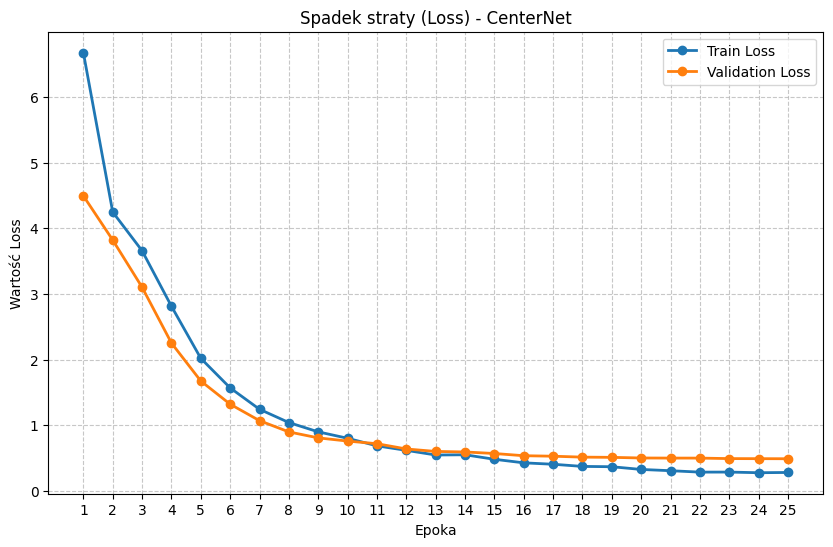

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model3 = SimpleUNetCenterNet(num_classes=2)
train_model(model3, EPOCHS=25, transform=get_transform, subset_size=1000, id="3", val_subset=100, device=device)

In [4]:
evaluate_model(model3, transform=get_transform, id="3", device=device)

Rozpoczynam ewaluację CenterNet...


Ewaluacja:   0%|          | 0/156 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)
Ewaluacja: 100%|██████████| 156/156 [01:40<00:00,  1.56it/s]


--------------------------------------------------
WYNIKI EWALUACJI CENTERNET:
--------------------------------------------------
mAP@50-95:    0.5890
mAP@50:       0.6108
mAP@75:       0.6098
Recall (MAR): 0.6534
--------------------------------------------------
